# Data Understanding: Credit Card Fraud Dataset

This notebook performs an initial review of the raw transaction data before preprocessing or modelling. It focuses on dataset structure, data quality, target imbalance, and the most useful first observations.

**Dataset:** `data/raw/creditcard.csv`  
**Target:** `Class` — `0` for a legitimate transaction and `1` for a fraudulent transaction.

## 1. Setup and data loading

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("../data/raw/creditcard.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH.name}: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

Loaded creditcard.csv: 284,807 rows × 31 columns


## 2. First look at the records

The `V1`–`V28` fields are anonymized, PCA-transformed transaction features. `Time` is elapsed seconds from the first recorded transaction, while `Amount` remains in its original scale.

In [2]:
display(df.head())
display(df.sample(5, random_state=42))

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,"41,505.0000",-16.5265,8.5850,-18.6499,9.5056,-13.7938,-2.8324,-16.7017,7.5173,-8.5071,-14.1102,5.2992,-10.8340,1.6711,-9.3739,0.3608,-9.8992,-19.2363,-8.3986,3.1017,-1.5149,1.1907,-1.1277,-2.3586,0.6735,-1.4137,-0.4628,-2.0186,-1.0428,364.1900,1
49906,"44,261.0000",0.3398,-2.7437,-0.1341,-1.3857,-1.4514,1.0159,-0.5244,0.2241,0.8997,-0.5650,-0.0877,0.9794,0.0769,-0.2179,-0.1368,-2.1429,0.1270,1.7527,0.4325,0.5060,-0.2134,-0.9425,-0.5268,-1.1570,0.3112,-0.7466,0.0410,0.1020,520.1200,0
29474,"35,484.0000",1.3996,-0.5907,0.1686,-1.0300,-0.5398,0.0404,-0.7126,0.0023,-0.9717,0.7568,0.5438,0.1125,1.0754,-0.2458,0.1805,1.7699,-0.5332,-0.5333,1.1922,0.2129,0.1024,0.1683,-0.1666,-0.8102,0.5051,-0.2323,0.0114,0.0046,31.0000,0
276481,"167,123.0000",-0.4321,1.6479,-1.6694,-0.3495,0.7858,-0.6306,0.2770,0.5860,-0.4847,-1.3766,-1.3283,0.2236,1.1326,-0.5509,0.6166,0.4980,0.5022,0.9813,0.1013,-0.2446,0.3589,0.8737,-0.1786,-0.0172,-0.2074,-0.1578,-0.2374,0.0019,1.5000,0
278846,"168,473.0000",2.0142,-0.1374,-1.0158,0.3273,-0.1822,-0.9566,0.0432,-0.1607,0.3632,0.2595,0.9422,0.8500,-0.6162,0.5926,-0.6038,0.0911,-0.4719,-0.3338,0.4047,-0.2553,-0.2386,-0.6164,0.3470,0.0616,-0.3602,0.1747,-0.0780,-0.0706,0.8900,0


## 3. Dataset structure and feature types

In [3]:
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notna().sum(),
    "unique_values": df.nunique(),
}).sort_index()
display(schema)

print("Dataset dimensions:", df.shape)
print("Memory usage: {:.2f} MB".format(df.memory_usage(deep=True).sum() / 1024**2))
print("Duplicate rows:", int(df.duplicated().sum()))

,dtype,non_null_count,unique_values
Amount,float64,284807,32767
Class,int64,284807,2
Time,float64,284807,124592
V1,float64,284807,275663
V10,float64,284807,275663
V11,float64,284807,275663
V12,float64,284807,275663
V13,float64,284807,275663
V14,float64,284807,275663
V15,float64,284807,275663


Dataset dimensions: (284807, 31)
Memory usage: 67.36 MB


Duplicate rows: 1081


## 4. Data quality checks

Check for missing values, duplicate observations, infinite values, and basic descriptive statistics. Missing values or invalid numeric values should be addressed before model development.

In [4]:
quality_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(3),
    "infinite_count": np.isinf(df.select_dtypes(include=np.number)).sum(),
})
display(quality_summary[quality_summary.sum(axis=1) > 0])

if quality_summary.sum().sum() == 0:
    print("No missing or infinite values found.")

display(df.describe().T)

,missing_count,missing_pct,infinite_count


No missing or infinite values found.


,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,"284,807.0000",-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


## 5. Target distribution and class imbalance

Fraud detection is typically a highly imbalanced classification problem. This section quantifies the imbalance and visualizes the target distribution.

,count,percentage
Class,,
Legitimate (0),284315,99.8273
Fraud (1),492,0.1727


Fraud rate: 0.1727%
Legitimate-to-fraud ratio: 577.9:1


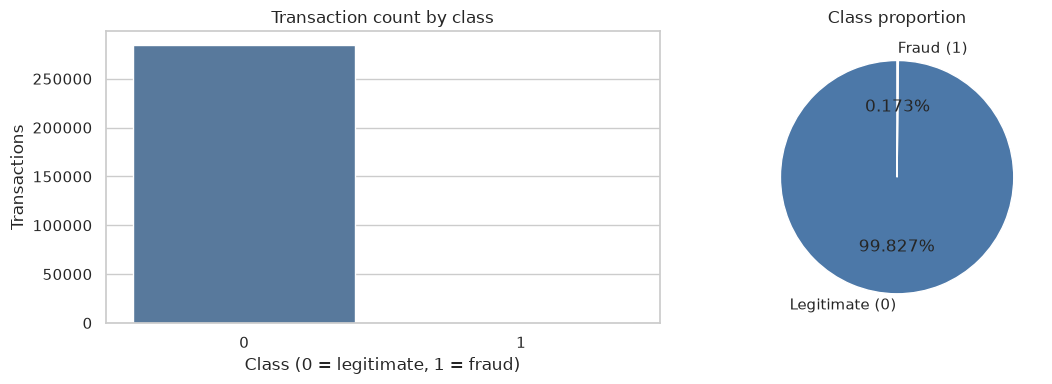

In [5]:
class_summary = (
    df["Class"].value_counts()
    .rename_axis("Class")
    .to_frame("count")
    .assign(percentage=lambda frame: (frame["count"] / len(df) * 100).round(4))
)
class_summary.index = class_summary.index.map({0: "Legitimate (0)", 1: "Fraud (1)"})
display(class_summary)

fraud_rate = df["Class"].mean() * 100
print(f"Fraud rate: {fraud_rate:.4f}%")
print(f"Legitimate-to-fraud ratio: {(df["Class"] == 0).sum() / (df["Class"] == 1).sum():.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="Class", hue="Class", palette=["#4C78A8", "#E45756"], legend=False, ax=axes[0])
axes[0].set(title="Transaction count by class", xlabel="Class (0 = legitimate, 1 = fraud)", ylabel="Transactions")
axes[0].ticklabel_format(style="plain", axis="y")
axes[1].pie(class_summary["percentage"], labels=class_summary.index, autopct="%1.3f%%", startangle=90, colors=["#4C78A8", "#E45756"])
axes[1].set_title("Class proportion")
plt.tight_layout()

## 6. Transaction amount analysis

Amounts are often right-skewed. Compare their summary statistics and log-scaled distributions by class to see whether fraudulent transactions have a different spending profile.

,Legitimate,Fraud
count,"284,315.0000",492.0000
mean,88.2910,122.2113
std,250.1051,256.6833
min,0.0000,0.0000
25%,5.6500,1.0000
50%,22.0000,9.2500
75%,77.0500,105.8900
max,"25,691.1600","2,125.8700"


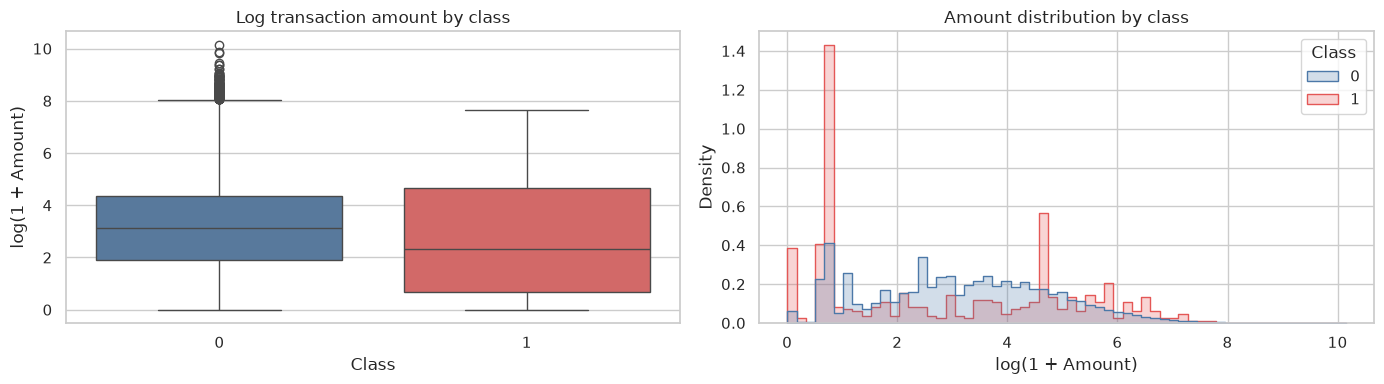

In [6]:
amount_summary = df.groupby("Class")["Amount"].describe().T
amount_summary.columns = ["Legitimate" if col == 0 else "Fraud" for col in amount_summary.columns]
display(amount_summary)

plot_data = df.assign(log_amount=np.log1p(df["Amount"]))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=plot_data, x="Class", y="log_amount", hue="Class", palette=["#4C78A8", "#E45756"], legend=False, ax=axes[0])
axes[0].set(title="Log transaction amount by class", xlabel="Class", ylabel="log(1 + Amount)")
sns.histplot(data=plot_data, x="log_amount", hue="Class", bins=60, stat="density", common_norm=False, element="step", palette=["#4C78A8", "#E45756"], ax=axes[1])
axes[1].set(title="Amount distribution by class", xlabel="log(1 + Amount)", ylabel="Density")
plt.tight_layout()

## 7. Time coverage and fraud timing

`Time` measures seconds from the first transaction, not a calendar timestamp. Converting it to hours makes the data-collection window and the timing of fraud easier to inspect.

Time range: 0.00 to 48.00 hours


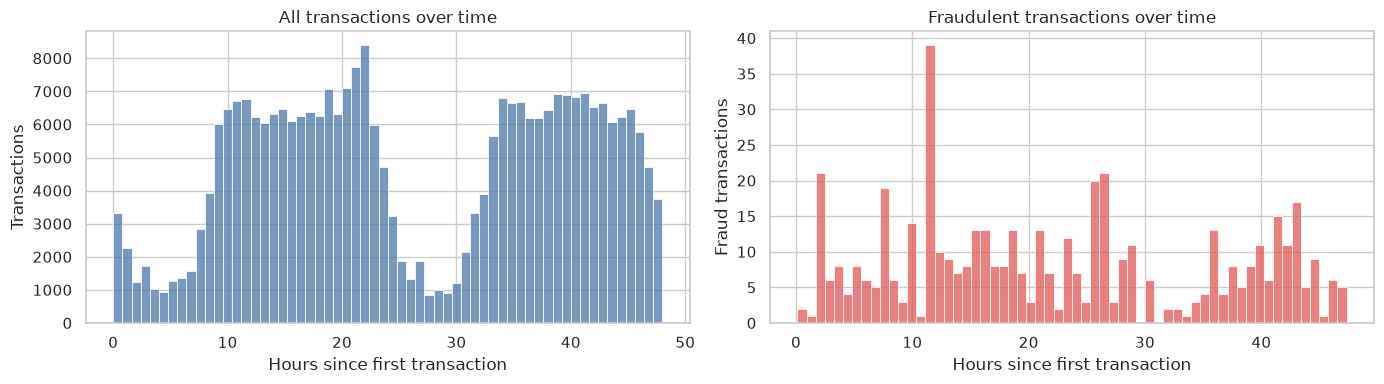

In [7]:
df["Time_hours"] = df["Time"] / 3600
print(f"Time range: {df["Time_hours"].min():.2f} to {df["Time_hours"].max():.2f} hours")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=df, x="Time_hours", bins=60, color="#4C78A8", ax=axes[0])
axes[0].set(title="All transactions over time", xlabel="Hours since first transaction", ylabel="Transactions")
sns.histplot(data=df[df["Class"] == 1], x="Time_hours", bins=60, color="#E45756", ax=axes[1])
axes[1].set(title="Fraudulent transactions over time", xlabel="Hours since first transaction", ylabel="Fraud transactions")
plt.tight_layout()

## 8. Feature relationship with the target

Correlation is only a first-pass signal and does not establish causation. For anonymized PCA components, it helps identify features worth retaining for the initial baseline models.

,correlation_with_class
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V11,0.1549
V4,0.1334
V18,-0.1115


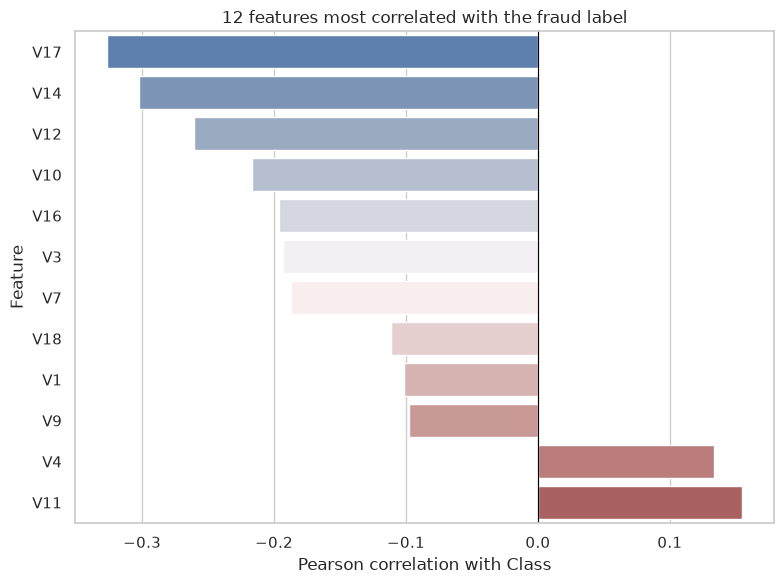

In [8]:
numeric_features = df.drop(columns="Time_hours").select_dtypes(include=np.number)
target_correlations = numeric_features.corr()["Class"].drop("Class").sort_values(key=np.abs, ascending=False)
display(target_correlations.rename("correlation_with_class").to_frame())

top_features = target_correlations.head(12).sort_values()
plt.figure(figsize=(8, 6))
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette="vlag", legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("12 features most correlated with the fraud label")
plt.xlabel("Pearson correlation with Class")
plt.ylabel("Feature")
plt.tight_layout()

## 9. Initial findings and modelling implications

Run the cell below after the analyses above to generate a concise, data-driven handoff for preprocessing and model development.

In [9]:
n_fraud = int((df["Class"] == 1).sum())
n_legitimate = int((df["Class"] == 0).sum())
top_three = ", ".join(target_correlations.head(3).index)

findings = [
    f"The dataset contains {len(df):,} transactions and {df.shape[1] - 1:,} original columns, with no missing or infinite values detected.",
    f"Only {n_fraud:,} transactions ({fraud_rate:.4f}%) are fraudulent, compared with {n_legitimate:,} legitimate transactions.",
    f"The strongest linear associations with the fraud label are currently: {top_three}.",
    "Use stratified train/test splits and fraud-aware metrics (precision, recall, PR-AUC, and ROC-AUC); accuracy alone will be misleading.",
    "Fit transformations, scaling, and any resampling only on training data to prevent data leakage.",
]
for number, finding in enumerate(findings, start=1):
    print(f"{number}. {finding}")

1. The dataset contains 284,807 transactions and 31 original columns, with no missing or infinite values detected.
2. Only 492 transactions (0.1727%) are fraudulent, compared with 284,315 legitimate transactions.
3. The strongest linear associations with the fraud label are currently: V17, V14, V12.
4. Use stratified train/test splits and fraud-aware metrics (precision, recall, PR-AUC, and ROC-AUC); accuracy alone will be misleading.
5. Fit transformations, scaling, and any resampling only on training data to prevent data leakage.
